# 📚 End-to-End Books Recommender System
> Collaborative Filtering · KNN · MLflow/DagsHub · Modular Pipeline

**Architecture:** Data Ingestion → Data Validation → Data Transformation → Model Trainer → Recommendation Engine


## ⚙️ Step 0 — Install Dependencies

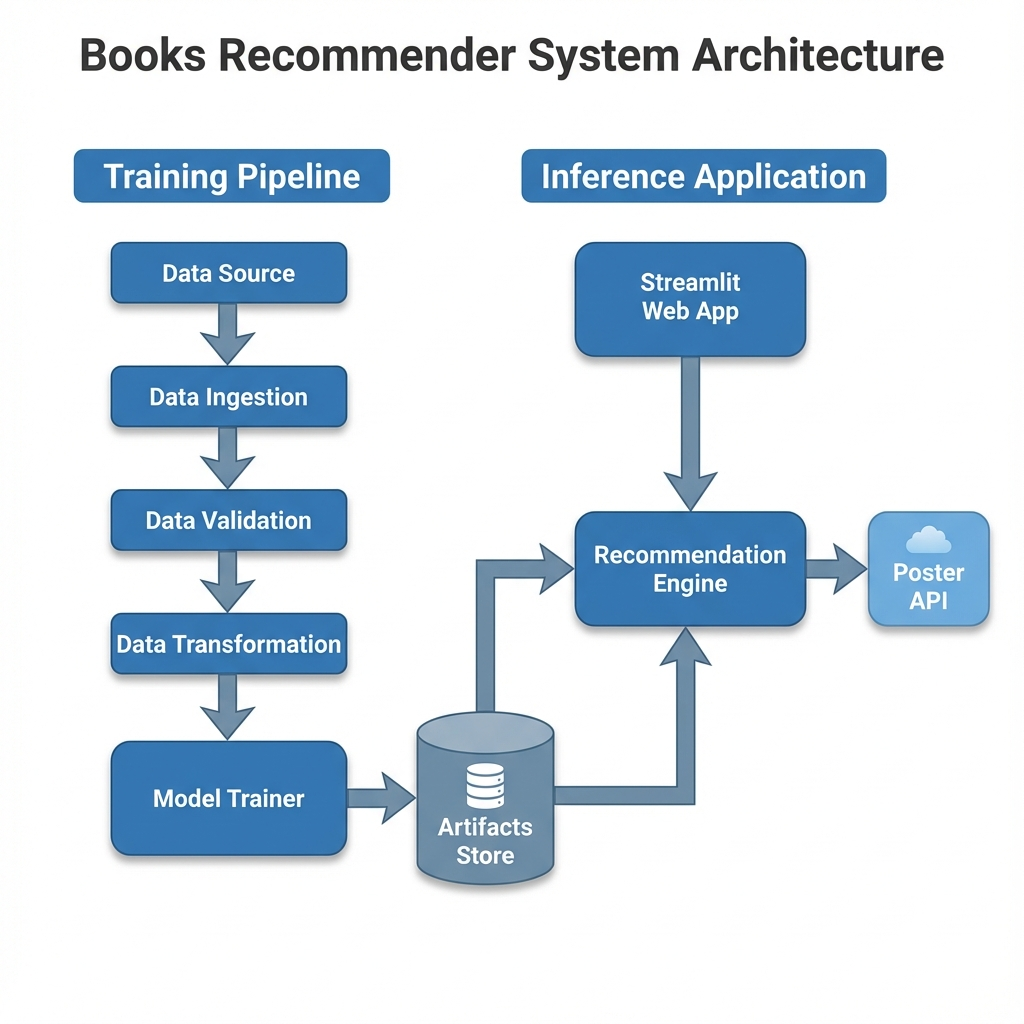

In [26]:
from IPython.display import Image, display

# Display the image
display(Image('/content/architecture_diagram (5).jpg'))

In [1]:
!pip install scikit-learn pandas numpy PyYAML mlflow dagshub scipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83

## 🔐 Step 1 — Set Environment Variables (from Colab Secrets)

In [2]:
import os
from google.colab import userdata

# ── MongoDB (from Colab Secrets) ──────────────────────────────────────────────
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# ── MLflow / DagsHub ──────────────────────────────────────────────────────────
USE_DAGSHUB = True  # ✅ Set False to use local MLflow

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow — logs saved inside Colab
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('✅ Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")

✅ Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


## 🏗️ Step 2 — Build Project Structure

In [3]:
import os
from pathlib import Path

PROJECT_ROOT = os.getcwd()  # /content in Colab

dirs = [
    "books_recommender",
    "books_recommender/components",
    "books_recommender/config",
    "books_recommender/constant",
    "books_recommender/entity",
    "books_recommender/exception",
    "books_recommender/logger",
    "books_recommender/pipeline",
    "books_recommender/utils",
    "config",
    "logs",
    "artifacts",
    "notebook",
]

for d in dirs:
    os.makedirs(d, exist_ok=True)

# Create __init__.py for all sub-packages
init_paths = [
    "books_recommender/__init__.py",
    "books_recommender/components/__init__.py",
    "books_recommender/config/__init__.py",
    "books_recommender/constant/__init__.py",
    "books_recommender/entity/__init__.py",
    "books_recommender/exception/__init__.py",
    "books_recommender/logger/__init__.py",
    "books_recommender/pipeline/__init__.py",
    "books_recommender/utils/__init__.py",
]
for p in init_paths:
    Path(p).touch()

print('✅ Project structure created.')

✅ Project structure created.


## 📝 Step 3 — Write Source Files

### 3.1 — config/config.yaml

In [4]:
config_yaml = """\
artifacts_config:
  artifacts_dir: artifacts

data_ingestion_config:
  dataset_download_url: https://github.com/entbappy/Branching-tutorial/raw/master/books_data.zip
  dataset_dir: dataset
  ingested_dir: ingested_data
  raw_data_dir: raw_data

data_validation_config:
  clean_data_dir: clean_data
  serialized_objects_dir: serialized_objects
  books_csv_file: BX-Books.csv
  ratings_csv_file: BX-Book-Ratings.csv

data_transformation_config:
  transformed_data_dir: transformed_data

model_trainer_config:
  trained_model_dir: trained_model
  trained_model_name: model.pkl

recommendation_config:
  poster_api_url: https://api.themoviedb.org/3/movie/{}?api_key=8265bd1679663a7ea12ac168da84d2e8&language=en-US
"""

with open('config/config.yaml', 'w') as f:
    f.write(config_yaml)

print('✅ config/config.yaml written.')

✅ config/config.yaml written.


### 3.2 — Logger

In [5]:
log_py = '''\
import logging
import os
from datetime import datetime

LOG_DIR = os.path.join(os.getcwd(), "logs")
os.makedirs(LOG_DIR, exist_ok=True)

CURRENT_TIME_STAMP = f"{datetime.now().strftime(\x27%Y-%m-%d-%H-%M-%S\x27)}"
file_name = f"log_{CURRENT_TIME_STAMP}.log"
log_file_path = os.path.join(LOG_DIR, file_name)

logging.basicConfig(
    filename=log_file_path,
    filemode=\x27w\x27,
    format=\x27[%(asctime)s] %(name)s - %(levelname)s - %(message)s\x27,
    level=logging.NOTSET
)
'''

with open('books_recommender/logger/log.py', 'w') as f:
    f.write(log_py)
print('✅ logger/log.py written.')

✅ logger/log.py written.


### 3.3 — Exception Handler

In [6]:
exception_py = '''\
import sys

class AppException(Exception):
    def __init__(self, error_message: Exception, error_detail: sys):
        super().__init__(error_message)
        self.error_message = AppException.error_message_detail(error_message, error_detail=error_detail)

    @staticmethod
    def error_message_detail(error: Exception, error_detail: sys):
        _, _, exc_tb = error_detail.exc_info()
        file_name = exc_tb.tb_frame.f_code.co_filename
        error_message = (
            f"Error occurred python script name [{file_name}]"
            f" line number [{exc_tb.tb_lineno}] error message [{error}]."
        )
        return error_message

    def __repr__(self):
        return AppException.__name__.__str__()

    def __str__(self):
        return self.error_message
'''

with open('books_recommender/exception/exception_handler.py', 'w') as f:
    f.write(exception_py)
print('✅ exception/exception_handler.py written.')

✅ exception/exception_handler.py written.


### 3.4 — Utils

In [7]:
util_py = '''\
import yaml
import sys
from books_recommender.exception.exception_handler import AppException

def read_yaml_file(file_path: str) -> dict:
    try:
        with open(file_path, \x27rb\x27) as yaml_file:
            return yaml.safe_load(yaml_file)
    except Exception as e:
        raise AppException(e, sys) from e
'''

with open('books_recommender/utils/util.py', 'w') as f:
    f.write(util_py)
print('✅ utils/util.py written.')

✅ utils/util.py written.


### 3.5 — Constant

In [8]:
constant_init = '''\
import os

ROOT_DIR = os.getcwd()
CONFIG_FOLDER_NAME = "config"
CONFIG_FILE_NAME = "config.yaml"
CONFIG_FILE_PATH = os.path.join(ROOT_DIR, CONFIG_FOLDER_NAME, CONFIG_FILE_NAME)
'''

with open('books_recommender/constant/__init__.py', 'w') as f:
    f.write(constant_init)
print('✅ constant/__init__.py written.')

✅ constant/__init__.py written.


### 3.6 — Entity (Config Namedtuples)

In [9]:
entity_py = '''\
from collections import namedtuple

DataIngestionConfig = namedtuple("DataIngestionConfig", [
    "dataset_download_url", "raw_data_dir", "ingested_dir"
])

DataValidationConfig = namedtuple("DataValidationConfig", [
    "clean_data_dir", "books_csv_file", "ratings_csv_file", "serialized_objects_dir"
])

DataTransformationConfig = namedtuple("DataTransformationConfig", [
    "clean_data_file_path", "transformed_data_dir"
])

ModelTrainerConfig = namedtuple("ModelTrainerConfig", [
    "transformed_data_file_dir", "trained_model_dir", "trained_model_name"
])

ModelRecommendationConfig = namedtuple("ModelRecommendationConfig", [
    "book_name_serialized_objects", "book_pivot_serialized_objects",
    "final_rating_serialized_objects", "trained_model_path"
])
'''

with open('books_recommender/entity/config_entity.py', 'w') as f:
    f.write(entity_py)
print('✅ entity/config_entity.py written.')

✅ entity/config_entity.py written.


### 3.7 — Configuration

In [10]:
configuration_py = '''\
import os
import sys
from books_recommender.logger.log import logging
from books_recommender.utils.util import read_yaml_file
from books_recommender.exception.exception_handler import AppException
from books_recommender.entity.config_entity import (
    DataIngestionConfig, DataValidationConfig,
    DataTransformationConfig, ModelTrainerConfig, ModelRecommendationConfig
)
from books_recommender.constant import *


class AppConfiguration:
    def __init__(self, config_file_path: str = CONFIG_FILE_PATH):
        try:
            self.configs_info = read_yaml_file(file_path=config_file_path)
        except Exception as e:
            raise AppException(e, sys) from e

    def get_data_ingestion_config(self) -> DataIngestionConfig:
        try:
            cfg = self.configs_info[\x27data_ingestion_config\x27]
            artifacts_dir = self.configs_info[\x27artifacts_config\x27][\x27artifacts_dir\x27]
            dataset_dir = cfg[\x27dataset_dir\x27]
            ingested_data_dir = os.path.join(artifacts_dir, dataset_dir, cfg[\x27ingested_dir\x27])
            raw_data_dir = os.path.join(artifacts_dir, dataset_dir, cfg[\x27raw_data_dir\x27])
            response = DataIngestionConfig(
                dataset_download_url=cfg[\x27dataset_download_url\x27],
                raw_data_dir=raw_data_dir,
                ingested_dir=ingested_data_dir
            )
            logging.info(f"Data Ingestion Config: {response}")
            return response
        except Exception as e:
            raise AppException(e, sys) from e

    def get_data_validation_config(self) -> DataValidationConfig:
        try:
            dv = self.configs_info[\x27data_validation_config\x27]
            di = self.configs_info[\x27data_ingestion_config\x27]
            artifacts_dir = self.configs_info[\x27artifacts_config\x27][\x27artifacts_dir\x27]
            dataset_dir = di[\x27dataset_dir\x27]
            ingested_dir = os.path.join(artifacts_dir, dataset_dir, di[\x27ingested_dir\x27])
            response = DataValidationConfig(
                clean_data_dir=os.path.join(artifacts_dir, dataset_dir, dv[\x27clean_data_dir\x27]),
                books_csv_file=os.path.join(ingested_dir, dv[\x27books_csv_file\x27]),
                ratings_csv_file=os.path.join(ingested_dir, dv[\x27ratings_csv_file\x27]),
                serialized_objects_dir=os.path.join(artifacts_dir, dv[\x27serialized_objects_dir\x27])
            )
            logging.info(f"Data Validation Config: {response}")
            return response
        except Exception as e:
            raise AppException(e, sys) from e

    def get_data_transformation_config(self) -> DataTransformationConfig:
        try:
            dt = self.configs_info[\x27data_transformation_config\x27]
            dv = self.configs_info[\x27data_validation_config\x27]
            di = self.configs_info[\x27data_ingestion_config\x27]
            artifacts_dir = self.configs_info[\x27artifacts_config\x27][\x27artifacts_dir\x27]
            dataset_dir = di[\x27dataset_dir\x27]
            response = DataTransformationConfig(
                clean_data_file_path=os.path.join(artifacts_dir, dataset_dir, dv[\x27clean_data_dir\x27], \x27clean_data.csv\x27),
                transformed_data_dir=os.path.join(artifacts_dir, dataset_dir, dt[\x27transformed_data_dir\x27])
            )
            logging.info(f"Data Transformation Config: {response}")
            return response
        except Exception as e:
            raise AppException(e, sys) from e

    def get_model_trainer_config(self) -> ModelTrainerConfig:
        try:
            mt = self.configs_info[\x27model_trainer_config\x27]
            dt = self.configs_info[\x27data_transformation_config\x27]
            di = self.configs_info[\x27data_ingestion_config\x27]
            artifacts_dir = self.configs_info[\x27artifacts_config\x27][\x27artifacts_dir\x27]
            dataset_dir = di[\x27dataset_dir\x27]
            response = ModelTrainerConfig(
                transformed_data_file_dir=os.path.join(artifacts_dir, dataset_dir, dt[\x27transformed_data_dir\x27], \x27transformed_data.pkl\x27),
                trained_model_dir=os.path.join(artifacts_dir, mt[\x27trained_model_dir\x27]),
                trained_model_name=mt[\x27trained_model_name\x27]
            )
            logging.info(f"Model Trainer Config: {response}")
            return response
        except Exception as e:
            raise AppException(e, sys) from e

    def get_recommendation_config(self) -> ModelRecommendationConfig:
        try:
            rc = self.configs_info[\x27recommendation_config\x27]
            mt = self.configs_info[\x27model_trainer_config\x27]
            dv = self.configs_info[\x27data_validation_config\x27]
            artifacts_dir = self.configs_info[\x27artifacts_config\x27][\x27artifacts_dir\x27]
            ser_dir = os.path.join(artifacts_dir, dv[\x27serialized_objects_dir\x27])
            trained_model_dir = os.path.join(artifacts_dir, mt[\x27trained_model_dir\x27])
            response = ModelRecommendationConfig(
                book_name_serialized_objects=os.path.join(ser_dir, \x27book_names.pkl\x27),
                book_pivot_serialized_objects=os.path.join(ser_dir, \x27book_pivot.pkl\x27),
                final_rating_serialized_objects=os.path.join(ser_dir, \x27final_rating.pkl\x27),
                trained_model_path=os.path.join(trained_model_dir, mt[\x27trained_model_name\x27])
            )
            logging.info(f"Model Recommendation Config: {response}")
            return response
        except Exception as e:
            raise AppException(e, sys) from e
'''

with open('books_recommender/config/configuration.py', 'w') as f:
    f.write(configuration_py)
print('✅ config/configuration.py written.')

✅ config/configuration.py written.


### 3.8 — Stage 00: Data Ingestion

In [11]:
stage00 = '''\
import os
import sys
import shutil
import zipfile
from urllib import request as urllib_request
from books_recommender.logger.log import logging
from books_recommender.exception.exception_handler import AppException
from books_recommender.config.configuration import AppConfiguration


# ─────────────────────────────────────────────────────────────────────────────
# Paths to your locally uploaded CSV files in Colab
# Adjust these paths if you uploaded the files elsewhere
# ─────────────────────────────────────────────────────────────────────────────
LOCAL_RATINGS_CSV  = "/content/BX-Book-Ratings.csv"   # uploaded via Colab UI
LOCAL_USERS_CSV    = "/content/BX-Users.csv"           # uploaded via Colab UI
LOCAL_BOOKS_CSV    = "/content/BX-Books.csv"           # saved locally in Colab


class DataIngestion:
    def __init__(self, app_config=AppConfiguration()):
        try:
            logging.info(f"{\'=\' * 20}Data Ingestion log started.{\'=\' * 20} ")
            self.data_ingestion_config = app_config.get_data_ingestion_config()
            self.data_validation_config = app_config.get_data_validation_config()
        except Exception as e:
            raise AppException(e, sys) from e

    def ingest_local_data(self):
        """
        Copies locally uploaded CSVs (BX-Books, BX-Book-Ratings, BX-Users)
        into the ingested_data directory so the rest of the pipeline can find them.
        """
        try:
            ingested_dir = self.data_ingestion_config.ingested_dir
            os.makedirs(ingested_dir, exist_ok=True)

            files_to_copy = [
                (LOCAL_BOOKS_CSV,   "BX-Books.csv"),
                (LOCAL_RATINGS_CSV, "BX-Book-Ratings.csv"),
                (LOCAL_USERS_CSV,   "BX-Users.csv"),
            ]

            for src, dest_name in files_to_copy:
                dest = os.path.join(ingested_dir, dest_name)
                if os.path.exists(src):
                    shutil.copy2(src, dest)
                    logging.info(f"Copied {src} -> {dest}")
                else:
                    logging.warning(f"File not found, skipping: {src}")
                    print(f"⚠️  WARNING: {src} not found. Please upload it to Colab.")

            logging.info(f"All local data files copied to {ingested_dir}")
        except Exception as e:
            raise AppException(e, sys) from e

    def initiate_data_ingestion(self):
        try:
            self.ingest_local_data()
            logging.info(f"{\'=\' * 20}Data Ingestion log completed.{\'=\' * 20} \\n\\n")
        except Exception as e:
            raise AppException(e, sys) from e
'''

with open('books_recommender/components/stage_00_data_ingestion.py', 'w') as f:
    f.write(stage00)
print('✅ stage_00_data_ingestion.py written.')

✅ stage_00_data_ingestion.py written.


### 3.9 — Stage 01: Data Validation

In [12]:
stage01 = '''\
import os
import sys
import pickle
import pandas as pd
from books_recommender.logger.log import logging
from books_recommender.config.configuration import AppConfiguration
from books_recommender.exception.exception_handler import AppException


class DataValidation:
    def __init__(self, app_config=AppConfiguration()):
        try:
            self.data_validation_config = app_config.get_data_validation_config()
        except Exception as e:
            raise AppException(e, sys) from e

    def preprocess_data(self):
        try:
            ratings = pd.read_csv(
                self.data_validation_config.ratings_csv_file,
                sep=";", on_bad_lines="skip", encoding="latin-1"
            )
            books = pd.read_csv(
                self.data_validation_config.books_csv_file,
                sep=";", on_bad_lines="skip", encoding="latin-1"
            )

            logging.info(f"Shape of ratings: {ratings.shape}")
            logging.info(f"Shape of books:   {books.shape}")
            print(f"📖 Ratings shape: {ratings.shape}  |  Books shape: {books.shape}")

            # Keep relevant columns and rename
            books = books[[\x27ISBN\x27, \x27Book-Title\x27, \x27Book-Author\x27,
                           \x27Year-Of-Publication\x27, \x27Publisher\x27, \x27Image-URL-L\x27]]
            books.rename(columns={
                \x27Book-Title\x27: \x27title\x27, \x27Book-Author\x27: \x27author\x27,
                \x27Year-Of-Publication\x27: \x27year\x27, \x27Publisher\x27: \x27publisher\x27,
                \x27Image-URL-L\x27: \x27image_url\x27
            }, inplace=True)

            ratings.rename(columns={\x27User-ID\x27: \x27user_id\x27, \x27Book-Rating\x27: \x27rating\x27}, inplace=True)

            # Keep users with > 200 ratings
            x = ratings[\x27user_id\x27].value_counts() > 200
            y = x[x].index
            ratings = ratings[ratings[\x27user_id\x27].isin(y)]

            # Merge and filter books with >= 50 ratings
            ratings_with_books = ratings.merge(books, on=\x27ISBN\x27)
            number_rating = ratings_with_books.groupby(\x27title\x27)[\x27rating\x27].count().reset_index()
            number_rating.rename(columns={\x27rating\x27: \x27num_of_rating\x27}, inplace=True)
            final_rating = ratings_with_books.merge(number_rating, on=\x27title\x27)
            final_rating = final_rating[final_rating[\x27num_of_rating\x27] >= 50]
            final_rating.drop_duplicates([\x27user_id\x27, \x27title\x27], inplace=True)

            logging.info(f"Shape of final clean dataset: {final_rating.shape}")
            print(f"✅ Clean dataset shape: {final_rating.shape}")

            # Save clean CSV
            os.makedirs(self.data_validation_config.clean_data_dir, exist_ok=True)
            clean_path = os.path.join(self.data_validation_config.clean_data_dir, \x27clean_data.csv\x27)
            final_rating.to_csv(clean_path, index=False)
            logging.info(f"Saved clean data to {clean_path}")

            # Save serialized objects
            os.makedirs(self.data_validation_config.serialized_objects_dir, exist_ok=True)
            ser_dir = self.data_validation_config.serialized_objects_dir
            pickle.dump(final_rating, open(os.path.join(ser_dir, \x27final_rating.pkl\x27), \x27wb\x27))
            logging.info(f"Saved final_rating.pkl to {ser_dir}")

        except Exception as e:
            raise AppException(e, sys) from e

    def initiate_data_validation(self):
        try:
            logging.info(f"{\'=\' * 20}Data Validation log started.{\'=\' * 20} ")
            self.preprocess_data()
            logging.info(f"{\'=\' * 20}Data Validation log completed.{\'=\' * 20} \\n\\n")
        except Exception as e:
            raise AppException(e, sys) from e
'''

with open('books_recommender/components/stage_01_data_validation.py', 'w') as f:
    f.write(stage01)
print('✅ stage_01_data_validation.py written.')

✅ stage_01_data_validation.py written.


### 3.10 — Stage 02: Data Transformation

In [13]:
stage02 = '''\
import os
import sys
import pickle
import pandas as pd
from books_recommender.logger.log import logging
from books_recommender.config.configuration import AppConfiguration
from books_recommender.exception.exception_handler import AppException


class DataTransformation:
    def __init__(self, app_config=AppConfiguration()):
        try:
            self.data_transformation_config = app_config.get_data_transformation_config()
            self.data_validation_config = app_config.get_data_validation_config()
        except Exception as e:
            raise AppException(e, sys) from e

    def get_data_transformer(self):
        try:
            df = pd.read_csv(self.data_transformation_config.clean_data_file_path)

            # Create pivot table: rows=books, cols=users, values=ratings
            book_pivot = df.pivot_table(columns=\x27user_id\x27, index=\x27title\x27, values=\x27rating\x27)
            book_pivot.fillna(0, inplace=True)
            logging.info(f"Book pivot table shape: {book_pivot.shape}")
            print(f"📊 Pivot table shape: {book_pivot.shape}")

            # Save transformed data
            os.makedirs(self.data_transformation_config.transformed_data_dir, exist_ok=True)
            t_path = os.path.join(self.data_transformation_config.transformed_data_dir, \x27transformed_data.pkl\x27)
            pickle.dump(book_pivot, open(t_path, \x27wb\x27))
            logging.info(f"Saved transformed_data.pkl to {t_path}")

            # Save serialized objects for recommendation engine
            ser_dir = self.data_validation_config.serialized_objects_dir
            os.makedirs(ser_dir, exist_ok=True)

            book_names = book_pivot.index
            pickle.dump(book_names, open(os.path.join(ser_dir, \x27book_names.pkl\x27), \x27wb\x27))
            pickle.dump(book_pivot,  open(os.path.join(ser_dir, \x27book_pivot.pkl\x27),  \x27wb\x27))
            logging.info(f"Saved book_names.pkl and book_pivot.pkl to {ser_dir}")
            print(f"✅ Serialized objects saved to: {ser_dir}")

        except Exception as e:
            raise AppException(e, sys) from e

    def initiate_data_transformation(self):
        try:
            logging.info(f"{\'=\' * 20}Data Transformation log started.{\'=\' * 20} ")
            self.get_data_transformer()
            logging.info(f"{\'=\' * 20}Data Transformation log completed.{\'=\' * 20} \\n\\n")
        except Exception as e:
            raise AppException(e, sys) from e
'''

with open('books_recommender/components/stage_02_data_transformation.py', 'w') as f:
    f.write(stage02)
print('✅ stage_02_data_transformation.py written.')

✅ stage_02_data_transformation.py written.


### 3.11 — Stage 03: Model Trainer (with MLflow)

In [14]:
stage03 = '''\
import os
import sys
import pickle
import mlflow
import mlflow.sklearn
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from books_recommender.logger.log import logging
from books_recommender.config.configuration import AppConfiguration
from books_recommender.exception.exception_handler import AppException


class ModelTrainer:
    def __init__(self, app_config=AppConfiguration()):
        try:
            self.model_trainer_config = app_config.get_model_trainer_config()
        except Exception as e:
            raise AppException(e, sys) from e

    def train(self):
        try:
            # Load pivot data
            book_pivot = pickle.load(open(self.model_trainer_config.transformed_data_file_dir, \x27rb\x27))
            book_sparse = csr_matrix(book_pivot)

            algorithm = \x27brute\x27
            metric = \x27cosine\x27
            n_neighbors = 6

            # ── MLflow run ────────────────────────────────────────────────────
            mlflow.set_tracking_uri(os.environ.get(\x27MLFLOW_TRACKING_URI\x27, \x27./mlruns\x27))
            mlflow.set_experiment(\x27books_recommender\x27)

            with mlflow.start_run(run_name=\x27KNN_Collaborative_Filter\x27):
                model = NearestNeighbors(algorithm=algorithm, metric=metric, n_neighbors=n_neighbors)
                model.fit(book_sparse)

                # Log params
                mlflow.log_param(\x27algorithm\x27,   algorithm)
                mlflow.log_param(\x27metric\x27,      metric)
                mlflow.log_param(\x27n_neighbors\x27, n_neighbors)
                mlflow.log_param(\x27pivot_shape\x27, str(book_pivot.shape))

                # Log metrics
                mlflow.log_metric(\x27n_books\x27, book_pivot.shape[0])
                mlflow.log_metric(\x27n_users\x27, book_pivot.shape[1])

                # Log model
                mlflow.sklearn.log_model(model, artifact_path=\x27knn_model\x27)
                logging.info(f"MLflow run logged successfully.")
                print(f"✅ MLflow run logged. Tracking URI: {mlflow.get_tracking_uri()}")

            # Save model locally
            os.makedirs(self.model_trainer_config.trained_model_dir, exist_ok=True)
            file_name = os.path.join(
                self.model_trainer_config.trained_model_dir,
                self.model_trainer_config.trained_model_name
            )
            pickle.dump(model, open(file_name, \x27wb\x27))
            logging.info(f"Saved model to {file_name}")
            print(f"✅ Model saved to: {file_name}")

        except Exception as e:
            raise AppException(e, sys) from e

    def initiate_model_trainer(self):
        try:
            logging.info(f"{\'=\' * 20}Model Trainer log started.{\'=\' * 20} ")
            self.train()
            logging.info(f"{\'=\' * 20}Model Trainer log completed.{\'=\' * 20} \\n\\n")
        except Exception as e:
            raise AppException(e, sys) from e
'''

with open('books_recommender/components/stage_03_model_trainer.py', 'w') as f:
    f.write(stage03)
print('✅ stage_03_model_trainer.py written.')

✅ stage_03_model_trainer.py written.


### 3.12 — Training Pipeline

In [15]:
pipeline_py = '''\
from books_recommender.components.stage_00_data_ingestion import DataIngestion
from books_recommender.components.stage_01_data_validation import DataValidation
from books_recommender.components.stage_02_data_transformation import DataTransformation
from books_recommender.components.stage_03_model_trainer import ModelTrainer


class TrainingPipeline:
    def __init__(self):
        self.data_ingestion     = DataIngestion()
        self.data_validation    = DataValidation()
        self.data_transformation = DataTransformation()
        self.model_trainer      = ModelTrainer()

    def start_training_pipeline(self):
        print("\\n" + "="*50)
        print("🚀 STAGE 00 — Data Ingestion")
        print("="*50)
        self.data_ingestion.initiate_data_ingestion()

        print("\\n" + "="*50)
        print("🔍 STAGE 01 — Data Validation")
        print("="*50)
        self.data_validation.initiate_data_validation()

        print("\\n" + "="*50)
        print("🔄 STAGE 02 — Data Transformation")
        print("="*50)
        self.data_transformation.initiate_data_transformation()

        print("\\n" + "="*50)
        print("🤖 STAGE 03 — Model Training")
        print("="*50)
        self.model_trainer.initiate_model_trainer()

        print("\\n✅ Training Pipeline Completed Successfully!")
'''

with open('books_recommender/pipeline/training_pipeline.py', 'w') as f:
    f.write(pipeline_py)
print('✅ pipeline/training_pipeline.py written.')

✅ pipeline/training_pipeline.py written.


### 3.13 — setup.py

In [16]:
setup_py = '''\
from setuptools import setup, find_packages

setup(
    name="books_recommender",
    version="0.1.0",
    packages=find_packages(),
    install_requires=[]
)
'''

with open('setup.py', 'w') as f:
    f.write(setup_py)
print('✅ setup.py written.')

✅ setup.py written.


## 📦 Step 4 — Install Package (editable mode)

In [17]:
!pip install -e . -q
print('✅ books_recommender package installed in editable mode.')

  Preparing metadata (setup.py) ... done
✅ books_recommender package installed in editable mode.


## 📂 Step 5 — Upload Dataset Files

> **Before running the next cell**, please upload your 3 CSV files using the Colab file panel (📁 on the left sidebar):
> - `BX-Book-Ratings.csv` → upload to `/content/`
> - `BX-Users.csv`        → upload to `/content/`
> - `BX-Books.csv`        → should already be at `/content/BX-Books.csv`

Run the cell below to verify all files are present:

In [18]:
import os

required_files = [
    '/content/BX-Books.csv',
    '/content/BX-Book-Ratings.csv',
    '/content/BX-Users.csv',
]

all_ok = True
for f in required_files:
    exists = os.path.exists(f)
    status = '✅' if exists else '❌ MISSING'
    size   = f"{os.path.getsize(f)/1e6:.1f} MB" if exists else '—'
    print(f"{status}  {f}  ({size})")
    if not exists:
        all_ok = False

if all_ok:
    print('\n✅ All dataset files found. Ready to run pipeline!')
else:
    print('\n⚠️  Please upload missing files before proceeding.')

✅  /content/BX-Books.csv  (77.5 MB)
✅  /content/BX-Book-Ratings.csv  (29.5 MB)
✅  /content/BX-Users.csv  (12.0 MB)

✅ All dataset files found. Ready to run pipeline!


## 🚀 Step 6 — Run the Full Training Pipeline

In [19]:
from books_recommender.pipeline.training_pipeline import TrainingPipeline

pipeline = TrainingPipeline()
pipeline.start_training_pipeline()


🚀 STAGE 00 — Data Ingestion

🔍 STAGE 01 — Data Validation


/content/books_recommender/components/stage_01_data_validation.py:23: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv(


📖 Ratings shape: (1149780, 3)  |  Books shape: (271360, 8)
✅ Clean dataset shape: (59850, 9)

🔄 STAGE 02 — Data Transformation
📊 Pivot table shape: (742, 888)
✅ Serialized objects saved to: artifacts/serialized_objects

🤖 STAGE 03 — Model Training


2026/03/21 04:48:56 INFO mlflow.tracking.fluent: Experiment with name 'books_recommender' does not exist. Creating a new experiment.
2026/03/21 04:48:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/21 04:49:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/21 04:49:02 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


✅ MLflow run logged. Tracking URI: https://dagshub.com/prithusarkar90/networksecurity.mlflow
🏃 View run KNN_Collaborative_Filter at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/4/runs/bb8b15ca1a72412cb6ae6479680d9744
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/4
✅ Model saved to: artifacts/trained_model/model.pkl

✅ Training Pipeline Completed Successfully!


## 🔍 Step 7 — Verify Artifacts

In [20]:
import os

print("📁 Artifacts directory structure:")
for root, dirs, files in os.walk('artifacts'):
    level = root.replace('artifacts', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}📂 {os.path.basename(root)}/')
    for f in files:
        fpath = os.path.join(root, f)
        size = os.path.getsize(fpath)
        sub_indent = '  ' * (level + 1)
        print(f'{sub_indent}📄 {f}  ({size/1024:.1f} KB)')

📁 Artifacts directory structure:
📂 artifacts/
  📂 trained_model/
    📄 model.pkl  (178.9 KB)
  📂 dataset/
    📂 clean_data/
      📄 clean_data.csv  (8353.6 KB)
    📂 ingested_data/
      📄 BX-Book-Ratings.csv  (28840.3 KB)
      📄 BX-Books.csv  (75699.3 KB)
      📄 BX-Users.csv  (11723.9 KB)
    📂 transformed_data/
      📄 transformed_data.pkl  (5174.7 KB)
  📂 serialized_objects/
    📄 final_rating.pkl  (3722.1 KB)
    📄 book_pivot.pkl  (5174.7 KB)
    📄 book_names.pkl  (19.7 KB)


## 📚 Step 8 — Recommendation Engine (Inference)

In [21]:
import pickle
import numpy as np
from books_recommender.config.configuration import AppConfiguration

app_config = AppConfiguration()
rec_config = app_config.get_recommendation_config()

# Load artifacts
model      = pickle.load(open(rec_config.trained_model_path, 'rb'))
book_pivot = pickle.load(open(rec_config.book_pivot_serialized_objects, 'rb'))
final_rating = pickle.load(open(rec_config.final_rating_serialized_objects, 'rb'))
book_names = pickle.load(open(rec_config.book_name_serialized_objects, 'rb'))

print(f'✅ Artifacts loaded.')
print(f'   Total books available for recommendation: {len(book_names)}')


def recommend_book(book_name: str, n: int = 5):
    """Return top-n similar books with image URLs."""
    if book_name not in book_pivot.index:
        print(f"❌ '{book_name}' not found in the catalog.")
        return

    book_id = np.where(book_pivot.index == book_name)[0][0]
    _, suggestions = model.kneighbors(
        book_pivot.iloc[book_id, :].values.reshape(1, -1),
        n_neighbors=n + 1
    )

    results = []
    for idx in suggestions[0][1:]:   # skip index 0 (the query book itself)
        title = book_pivot.index[idx]
        row   = final_rating[final_rating['title'] == title]
        img   = row['image_url'].values[0] if not row.empty else 'N/A'
        results.append({'title': title, 'image_url': img})

    return results


print('\n📖 Sample books in catalog (first 10):')
for b in list(book_names[:10]):
    print(f'   • {b}')

✅ Artifacts loaded.
   Total books available for recommendation: 742

📖 Sample books in catalog (first 10):
   • 1984
   • 1st to Die: A Novel
   • 2nd Chance
   • 4 Blondes
   • 84 Charing Cross Road
   • A Bend in the Road
   • A Case of Need
   • A Child Called \It\": One Child's Courage to Survive"
   • A Civil Action
   • A Cry In The Night


In [22]:
# ── Change this to any book title from the catalog above ─────────────────────
QUERY_BOOK = list(book_names)[0]  # defaults to the first book

print(f"🔎 Finding books similar to: '{QUERY_BOOK}'\n")
recs = recommend_book(QUERY_BOOK, n=5)

if recs:
    print(f"{'#':<4} {'Title':<60} Image URL")
    print('-' * 100)
    for i, r in enumerate(recs, 1):
        print(f"{i:<4} {r['title']:<60} {r['image_url']}")

🔎 Finding books similar to: '1984'

#    Title                                                        Image URL
----------------------------------------------------------------------------------------------------
1    Animal Farm                                                  http://images.amazon.com/images/P/0451526341.01.LZZZZZZZ.jpg
2    The Catcher in the Rye                                       http://images.amazon.com/images/P/0316769487.01.LZZZZZZZ.jpg
3    Lord of the Flies                                            http://images.amazon.com/images/P/0399501487.01.LZZZZZZZ.jpg
4    The Handmaid's Tale                                          http://images.amazon.com/images/P/0449212602.01.LZZZZZZZ.jpg
5    Slaughterhouse Five or the Children's Crusade: A Duty Dance With Death http://images.amazon.com/images/P/0440180295.01.LZZZZZZZ.jpg


## 📊 Step 9 — EDA / Quick Insights

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

clean_df = pd.read_csv('artifacts/dataset/clean_data/clean_data.csv')
print(f'Clean dataset shape: {clean_df.shape}')
clean_df.head()

Clean dataset shape: (59850, 9)


,user_id,ISBN,rating,title,author,year,publisher,image_url,num_of_rating
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,82
1,277427,0060930535,0,The Poisonwood Bible: A Novel,Barbara Kingsolver,1999,Perennial,http://images.amazon.com/images/P/0060930535.0...,133
2,277427,0060934417,0,Bel Canto: A Novel,Ann Patchett,2002,Perennial,http://images.amazon.com/images/P/0060934417.0...,108
3,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,1995,HarperTorch,http://images.amazon.com/images/P/0061009059.0...,108
4,277427,006440188X,0,The Secret Garden,Frances Hodgson Burnett,1998,HarperTrophy,http://images.amazon.com/images/P/006440188X.0...,79


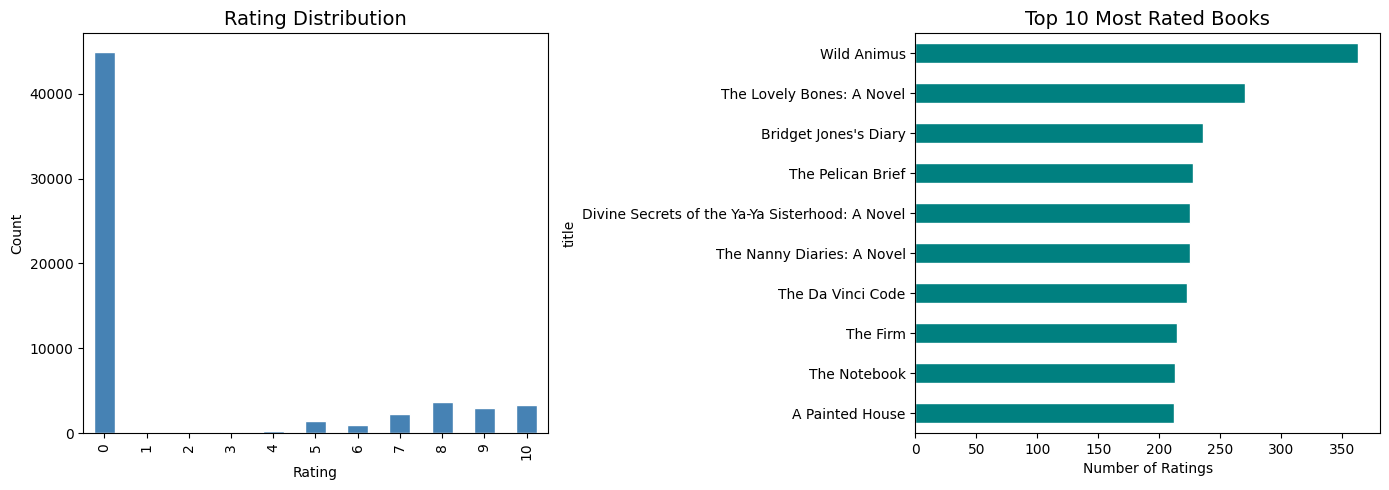

✅ EDA chart saved to notebook/eda_charts.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
clean_df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Rating Distribution', fontsize=14)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Top 10 most-rated books
top_books = clean_df['title'].value_counts().head(10)
top_books.plot(kind='barh', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Top 10 Most Rated Books', fontsize=14)
axes[1].set_xlabel('Number of Ratings')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('notebook/eda_charts.png', dpi=150)
plt.show()
print('✅ EDA chart saved to notebook/eda_charts.png')

## 🗜️ Step 10 — Export Project as ZIP

In [25]:
import shutil
import os

# Directories/files to include in the zip
include_dirs = [
    'books_recommender',
    'config',
    'artifacts',
    'logs',
    'notebook',
]
include_files = [
    'setup.py',
    'requirements.txt',
]

ZIP_NAME = 'books_recommender_project'
STAGE_DIR = f'/content/{ZIP_NAME}'
os.makedirs(STAGE_DIR, exist_ok=True)

for d in include_dirs:
    if os.path.exists(d):
        shutil.copytree(d, os.path.join(STAGE_DIR, d), dirs_exist_ok=True)

for f in include_files:
    if os.path.exists(f):
        shutil.copy2(f, STAGE_DIR)

# Write requirements.txt into the zip
req = "scikit-learn\npandas\nnumpy\nPyYAML\nmlflow\ndagshub\nscipy\n"
with open(os.path.join(STAGE_DIR, 'requirements.txt'), 'w') as rf:
    rf.write(req)

zip_path = shutil.make_archive(
    base_name=f'/content/{ZIP_NAME}',
    format='zip',
    root_dir='/content',
    base_dir=ZIP_NAME
)

size_mb = os.path.getsize(zip_path) / 1e6
print(f'✅ ZIP created: {zip_path}  ({size_mb:.1f} MB)')
print('   Download it from the Colab file panel (📁 left sidebar).')

✅ ZIP created: /content/books_recommender_project.zip  (28.5 MB)
   Download it from the Colab file panel (📁 left sidebar).


---
## ✅ Pipeline Complete!

| Stage | File | Status |
|---|---|---|
| Data Ingestion | `stage_00_data_ingestion.py` | Copies local CSVs to artifacts |
| Data Validation | `stage_01_data_validation.py` | Filters, merges, saves clean_data.csv |
| Data Transformation | `stage_02_data_transformation.py` | Pivot table + serialized objects |
| Model Trainer | `stage_03_model_trainer.py` | KNN + MLflow logging |
| Recommendation Engine | Inline (Step 8) | Inference using saved artifacts |

**Artifacts saved under:** `artifacts/`
**MLflow tracked at:** `MLFLOW_TRACKING_URI` (DagsHub or local)